In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import glob 

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


def improved_text_detector(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.equalizeHist(gray)

    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient = np.sqrt(grad_x ** 2 + grad_y ** 2)
    gradient = np.uint8(np.clip(gradient, 0, 255))

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    gradient = cv2.morphologyEx(gradient, cv2.MORPH_CLOSE, kernel)

    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    combined = cv2.bitwise_or(gradient, binary)

    kernel = np.ones((2, 2), np.uint8)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = w / h if h > 0 else 0
        area = w * h
        img_area = image.shape[0] * image.shape[1]

        if (area > 200 and
                area < img_area * 0.3 and
                aspect_ratio > 0.5 and
                aspect_ratio < 15 and
                h > 15 and w > 30):
            boxes.append([x, y, x + w, y + h])

    grouped_boxes = group_nearby_boxes(boxes, horizontal_gap=30, vertical_gap=15)

    return grouped_boxes


def group_nearby_boxes(boxes, horizontal_gap=30, vertical_gap=15):
    if not boxes:
        return []

    boxes = sorted(boxes, key=lambda b: (b[1], b[0]))

    grouped = []
    current_group = [boxes[0]]

    for box in boxes[1:]:
        last_box = current_group[-1]

        x_gap = box[0] - last_box[2]  # X
        y_gap = abs(box[1] - last_box[1])  # Y

        if x_gap < horizontal_gap and y_gap < vertical_gap:
            current_group.append(box)
        else:
            if len(current_group) > 0:
                min_x = min(b[0] for b in current_group)
                min_y = min(b[1] for b in current_group)
                max_x = max(b[2] for b in current_group)
                max_y = max(b[3] for b in current_group)

                padding = 5
                grouped.append([max(0, min_x - padding),
                                max(0, min_y - padding),
                                max_x + padding,
                                max_y + padding])

            current_group = [box]

    if current_group:
        min_x = min(b[0] for b in current_group)
        min_y = min(b[1] for b in current_group)
        max_x = max(b[2] for b in current_group)
        max_y = max(b[3] for b in current_group)
        padding = 5
        grouped.append([max(0, min_x - padding),
                        max(0, min_y - padding),
                        max_x + padding,
                        max_y + padding])

    return grouped


def text_detector_with_mser(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mser = cv2.MSER_create()
    mser.setMinArea(100)  # Минимальная площадь региона
    mser.setMaxArea(5000)  # Максимальная площадь региона

    regions, _ = mser.detectRegions(gray)

    mask = np.zeros(gray.shape, dtype=np.uint8)
    for region in regions:
        for point in region:
            mask[point[1], point[0]] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if w > 30 and h > 15 and w / h < 15 and h / w < 3:
            padding = 5
            boxes.append([max(0, x - padding),
                          max(0, y - padding),
                          min(image.shape[1], x + w + padding),
                          min(image.shape[0], y + h + padding)])

    grouped_boxes = group_nearby_boxes(boxes, horizontal_gap=40, vertical_gap=20)

    return grouped_boxes


def text_detector_with_contour_analysis(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    binary = cv2.adaptiveThreshold(blurred, 255,
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 4)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))
    kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 1))

    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_vertical)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_horizontal)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = w / h if h > 0 else 0
        area = w * h

        if (100 < area < 50000 and
                1.2 < aspect_ratio < 15 and
                h > 15 and w > 30):
            boxes.append([x, y, x + w, y + h])

    # Группировка
    grouped_boxes = group_nearby_boxes(boxes, horizontal_gap=25, vertical_gap=10)

    return grouped_boxes


# Тестируем все методы
test_files = glob.glob(r"H:\Coding\PyProjects\ocrTest\data\icdar2013\Challenge2_Test_Task12_Images\*.jpg")

if test_files:
    img = cv2.imread(test_files[1])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Метод 1: Улучшенный градиентный
    boxes1 = improved_text_detector(img)

    # Метод 2: MSER
    boxes2 = text_detector_with_mser(img)

    # Метод 3: Анализ контуров
    boxes3 = text_detector_with_contour_analysis(img)

    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Оригинал
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Оригинал")
    axes[0, 0].axis('off')

    # Метод 1
    img1 = img_rgb.copy()
    for box in boxes1:
        x1, y1, x2, y2 = box
        cv2.rectangle(img1, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[0, 1].imshow(img1)
    axes[0, 1].set_title(f"Градиентный метод: {len(boxes1)} областей")
    axes[0, 1].axis('off')

    # Метод 2
    img2 = img_rgb.copy()
    for box in boxes2:
        x1, y1, x2, y2 = box
        cv2.rectangle(img2, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1, 0].imshow(img2)
    axes[1, 0].set_title(f"MSER метод: {len(boxes2)} областей")
    axes[1, 0].axis('off')

    # Метод 3
    img3 = img_rgb.copy()
    for box in boxes3:
        x1, y1, x2, y2 = box
        cv2.rectangle(img3, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1, 1].imshow(img3)
    axes[1, 1].set_title(f"Анализ контуров: {len(boxes3)} областей")
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Выбираем лучший метод
    print(f"\nРезультаты:")
    print(f"Градиентный метод: {len(boxes1)} областей")
    print(f"MSER метод: {len(boxes2)} областей")
    print(f"Анализ контуров: {len(boxes3)} областей")

    # Рекомендуем лучший
    if len(boxes3) < len(boxes1) and len(boxes3) > 0:
        print("\n✅ Рекомендуется использовать метод анализа контуров")
        best_boxes = boxes3
    elif len(boxes2) < len(boxes1) and len(boxes2) > 0:
        print("\n✅ Рекомендуется использовать MSER метод")
        best_boxes = boxes2
    else:
        print("\n✅ Используйте улучшенный градиентный метод")
        best_boxes = boxes1

Скачиваем EAST модель...
Ошибка EAST: HTTP Error 404: Not Found


In [16]:
# Ячейка 3: Создаем CNN+RNN для распознавания текста

class SimpleCRNN(nn.Module):
    """Наша собственная нейросеть для распознавания текста"""

    def __init__(self, num_chars=36):  # 26 букв + 10 цифр
        super().__init__()

        # ===== CNN ЧАСТЬ (извлекает признаки букв) =====
        self.cnn = nn.Sequential(
            # Слой 1: смотрит на картинку и ищет простые признаки (линии, углы)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # уменьшает размер картинки в 2 раза

            # Слой 2: ищет более сложные признаки (буквы)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Слой 3: ищет целые буквы
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # ===== RNN ЧАСТЬ (читает последовательность букв) =====
        self.rnn = nn.LSTM(
            input_size=256 * 4,  # размер признаков
            hidden_size=128,  # размер памяти
            num_layers=2,  # глубина сети
            bidirectional=True  # читает и слева-направо, и справа-налево
        )

        # Финальный слой для предсказания букв
        self.fc = nn.Linear(256, num_chars)  # 256 = 128*2 (двунаправленная)

    def forward(self, x):
        # Применяем CNN
        cnn_features = self.cnn(x)  # картинка → набор признаков

        # Подготавливаем для RNN
        batch, channels, height, width = cnn_features.shape
        cnn_features = cnn_features.permute(3, 0, 1, 2)  # меняем порядок
        cnn_features = cnn_features.reshape(width, batch, -1)

        # Применяем RNN (читаем последовательно)
        rnn_output, _ = self.rnn(cnn_features)

        # Предсказываем буквы
        output = self.fc(rnn_output)

        return output


class MyOCR:
    """Наш собственный OCR"""

    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SimpleCRNN()
        self.model.to(self.device)

        # Буквы и цифры, которые умеет распознавать
        self.chars = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'

        # Преобразование картинки в формат для нейросети
        self.transform = transforms.Compose([
            transforms.Grayscale(),  # в черно-белый
            transforms.Resize((32, 128)),  # фиксированный размер
            transforms.ToTensor(),  # в тензор PyTorch
            transforms.Normalize(mean=[0.5], std=[0.5])  # нормализация
        ])

        print(f"OCR создан! Работает на {self.device}")
        print(f"Распознает {len(self.chars)} символов")

    def recognize(self, image_crop):
        """
        Распознает текст на маленькой картинке
        """
        # Подготовка картинки
        if isinstance(image_crop, np.ndarray):
            image_crop = Image.fromarray(image_crop)

        image_tensor = self.transform(image_crop).unsqueeze(0).to(self.device)

        # Распознавание
        with torch.no_grad():
            output = self.model(image_tensor)

        # Превращаем предсказания в текст
        output = output.permute(1, 0, 2)
        _, predictions = output.max(2)

        # Декодируем результат
        text = []
        prev_char = -1
        for p in predictions[0]:
            p = p.item()
            if p != prev_char and p < len(self.chars):
                text.append(self.chars[p])
            prev_char = p

        return ''.join(text)


my_ocr = MyOCR()

OCR создан! Работает на cpu
Распознает 36 символов


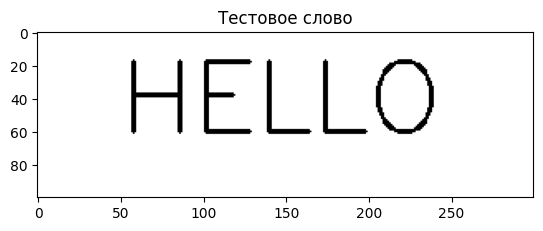

Распознано: N


In [17]:
def create_test_image():
    img = np.ones((100, 300, 3), dtype=np.uint8) * 255
    cv2.putText(img, 'HELLO', (50, 60), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)
    return img


test_img = create_test_image()
plt.imshow(test_img)
plt.title("Тестовое слово")
plt.show()

text = my_ocr.recognize(test_img)
print(f"Распознано: {text}")

Тестируем на реальном изображении из датасета:
Шаг 1: Поиск текста на картинке...
Найдено 67 областей с текстом
  Область 1: распознаю...
    Результат: 'N'
  Область 2: распознаю...
    Результат: 'N'
  Область 3: распознаю...
    Результат: 'N'
  Область 4: распознаю...
    Результат: 'N'
  Область 5: распознаю...
    Результат: 'N'
  Область 6: распознаю...
    Результат: 'N'
  Область 7: распознаю...
    Результат: 'N'
  Область 8: распознаю...
    Результат: 'N'
  Область 9: распознаю...
    Результат: 'N'
  Область 10: распознаю...
    Результат: 'N'
  Область 11: распознаю...
    Результат: 'N'
  Область 12: распознаю...
    Результат: 'N'
  Область 13: распознаю...
    Результат: 'N'
  Область 14: распознаю...
    Результат: 'N'
  Область 15: распознаю...
    Результат: 'N'
  Область 16: распознаю...
    Результат: 'N'
  Область 17: распознаю...
    Результат: 'N'
  Область 18: распознаю...
    Результат: 'N'
  Область 19: распознаю...
    Результат: 'N'
  Область 20: распознаю

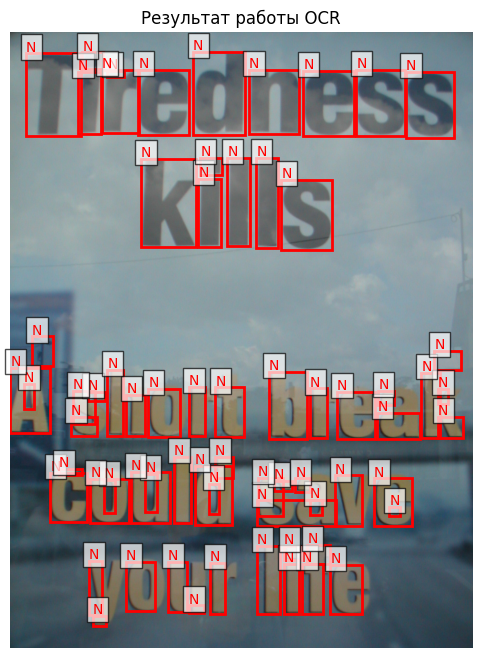

In [18]:
def simple_text_detector(image):
    pass


def full_ocr_pipeline(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Не удалось загрузить картинку")
        return []

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print("Шаг 1: Поиск текста на картинке...")
    text_boxes = simple_text_detector(image)
    print(f"Найдено {len(text_boxes)} областей с текстом")

    results = []
    for i, box in enumerate(text_boxes):
        x1, y1, x2, y2 = box

        text_crop = image_rgb[y1:y2, x1:x2]

        if text_crop.size == 0:
            continue

        print(f"  Область {i + 1}: распознаю...")
        recognized_text = my_ocr.recognize(text_crop)

        results.append({
            'text': recognized_text,
            'bbox': [x1, y1, x2, y2]
        })

        print(f"    Результат: '{recognized_text}'")

    return results


if test_files:
    print("Тестируем на реальном изображении из датасета:")
    print("=" * 50)
    results = full_ocr_pipeline(test_files[0])

    img = cv2.imread(test_files[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)

    for result in results:
        x1, y1, x2, y2 = result['bbox']
        text = result['text']

        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, color='red', linewidth=2)
        plt.gca().add_patch(rect)

        plt.text(x1, y1 - 5, text, fontsize=10, color='red',
                 bbox=dict(facecolor='white', alpha=0.7))

    plt.title("Результат работы OCR")
    plt.axis('off')
    plt.show()

In [12]:
class TextRecognitionPipeline:
    def __init__(self):
        self.detector = TextDetector()
        self.recognizer = TextRecognizer()

    def process_image(self, image_path):
        image = cv2.imread(image_path)
        if image is None:
            print(f"Не удалось загрузить изображение: {image_path}")
            return []

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        print("Ищем текст на изображении...")
        text_boxes = self.detector.detect_text_regions(image_path)

        if not text_boxes:
            print("Текст не найден")
            return []

        results = []
        for i, box_info in enumerate(text_boxes):
            bbox = box_info['bbox']
            x1, y1, x2, y2 = bbox

            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(image.shape[1], x2), min(image.shape[0], y2)

            text_crop = image_rgb[y1:y2, x1:x2]

            if text_crop.size == 0:
                continue

            recognized_text = self.recognizer.recognize(text_crop)

            results.append({
                'text': recognized_text,
                'bbox': bbox,
                'confidence': box_info['confidence']
            })

            print(f"Область {i + 1}: '{recognized_text}' (уверенность: {box_info['confidence']:.2f})")

        return results

    def visualize_results(self, image_path, results):
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(15, 10))
        plt.imshow(image_rgb)

        for result in results:
            x1, y1, x2, y2 = result['bbox']
            text = result['text']
            conf = result['confidence']

            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 fill=False, color='red', linewidth=2)
            plt.gca().add_patch(rect)

            plt.text(x1, y1 - 5, f"{text} ({conf:.2f})",
                     fontsize=10, color='red',
                     bbox=dict(facecolor='white', alpha=0.8))

        plt.axis('off')
        plt.title("Результаты распознавания текста")
        plt.show()